# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Bima Indra Sakti
- Email: bima.indr2506@gmail.com
- Id Dicoding: bimaindr

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
!pip install imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn import preprocessing
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

In [2]:
df = pd.read_csv('data.csv' ,sep=';')
df.head(5)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.isna().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [4]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [5]:
total_duplicates = df.duplicated().sum()
print(total_duplicates)

0


In [6]:
df.shape

(4424, 37)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [8]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

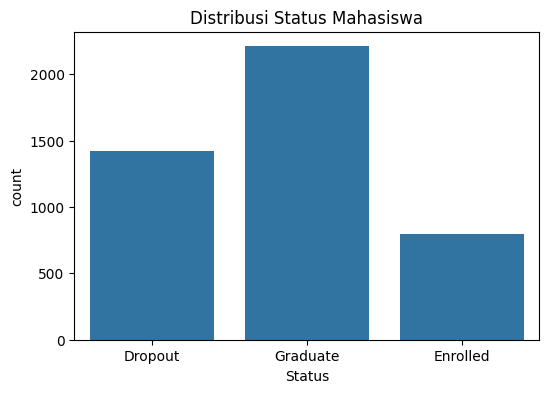

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df)
plt.title("Distribusi Status Mahasiswa")
plt.show()

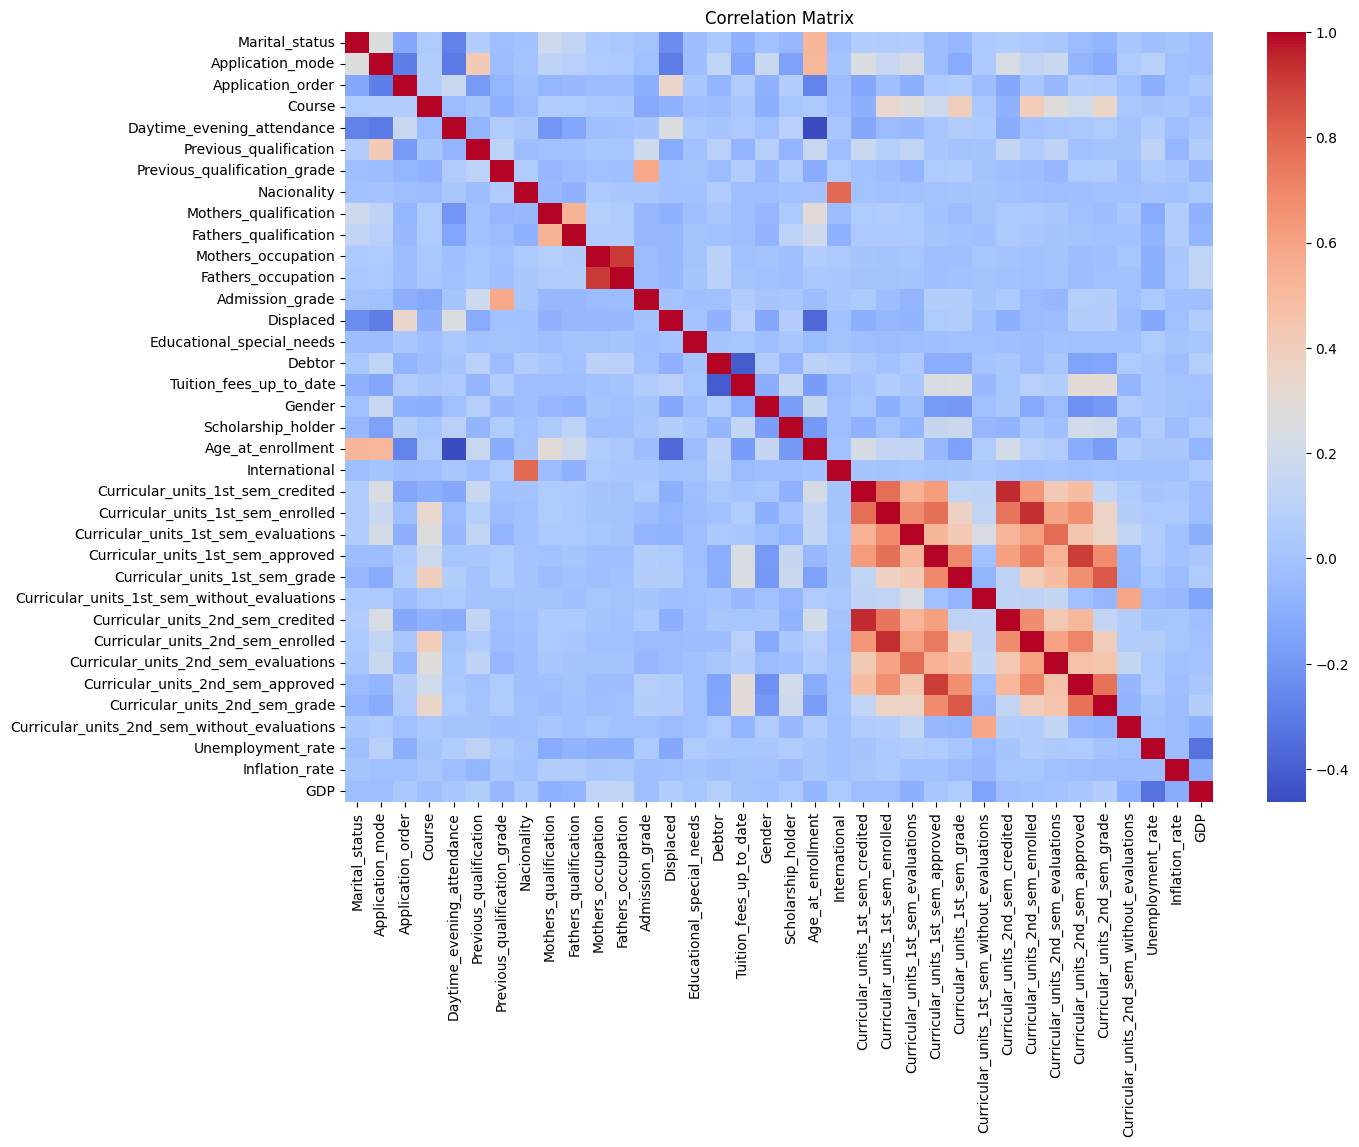

In [10]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

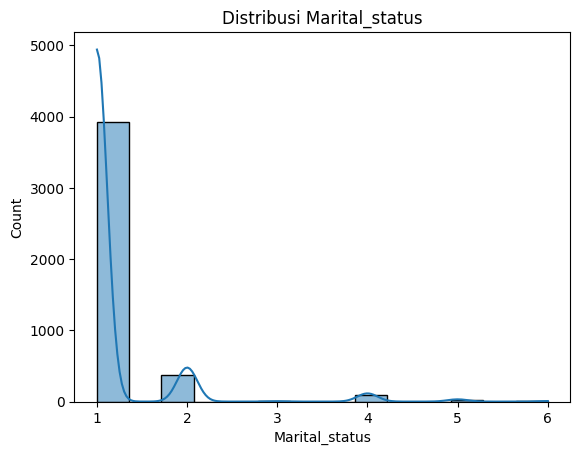

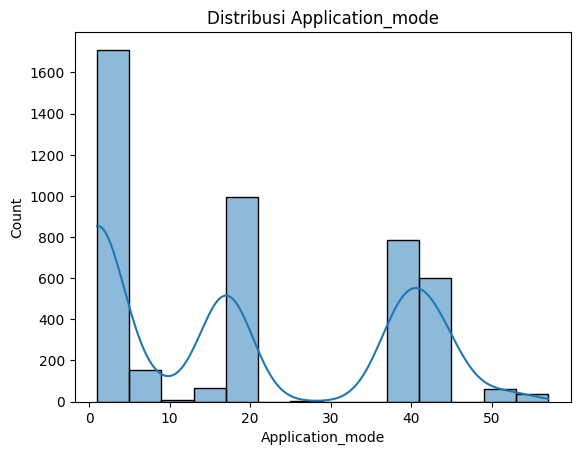

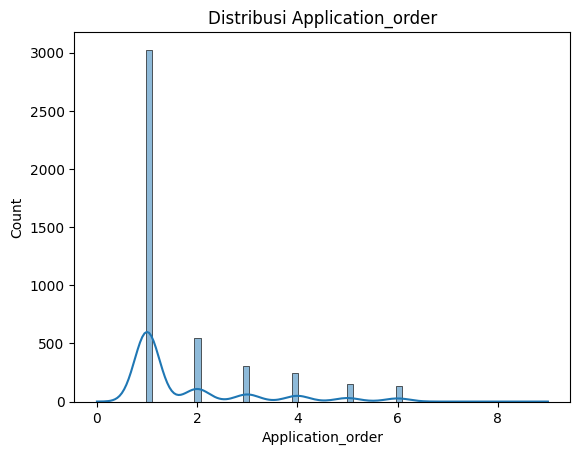

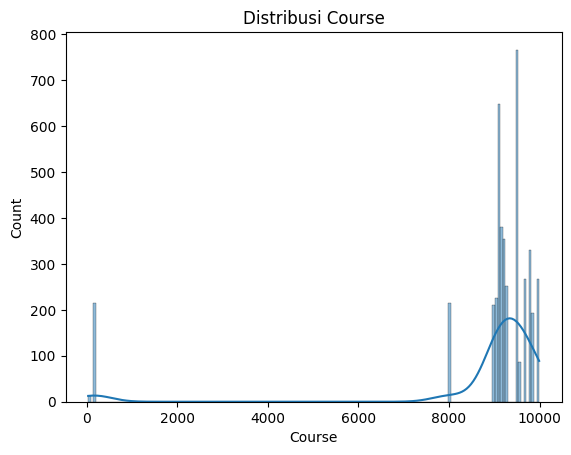

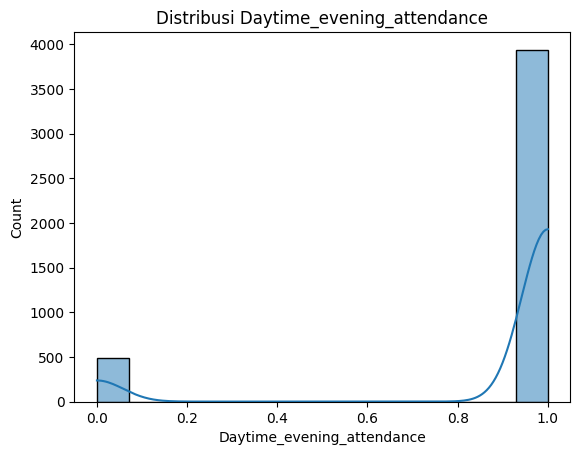

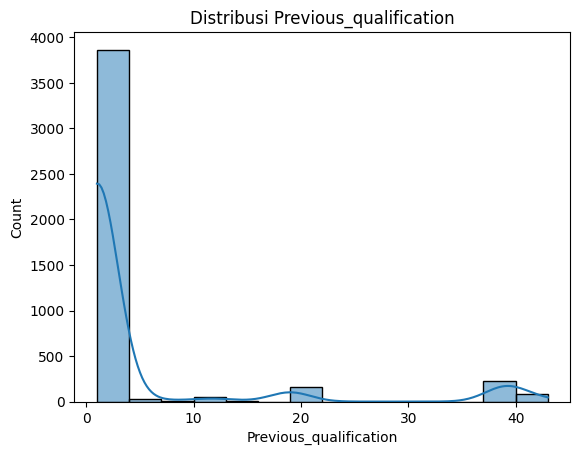

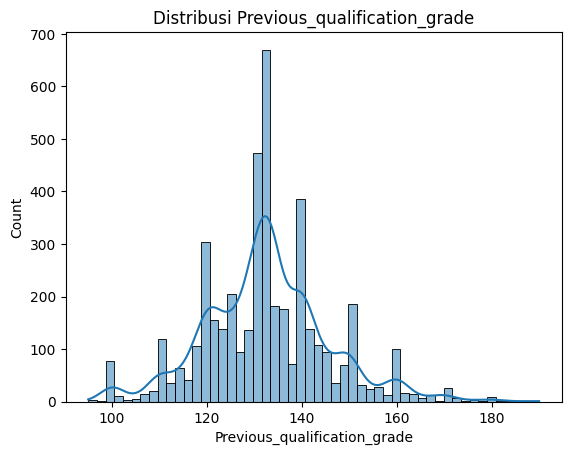

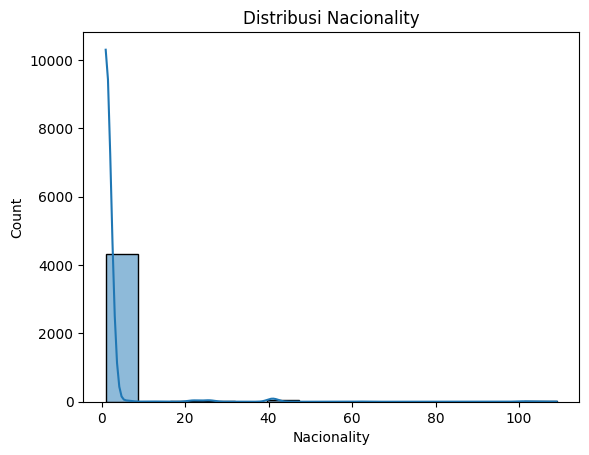

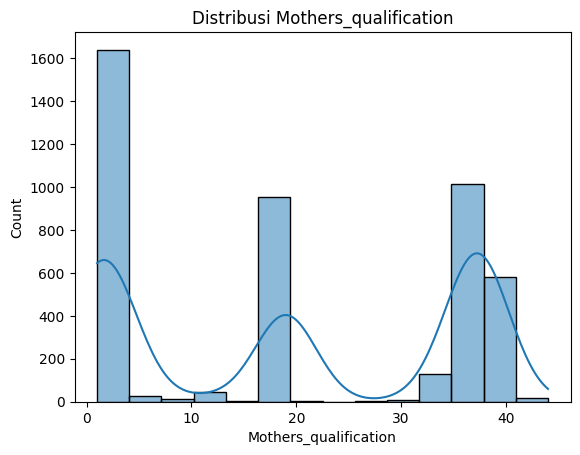

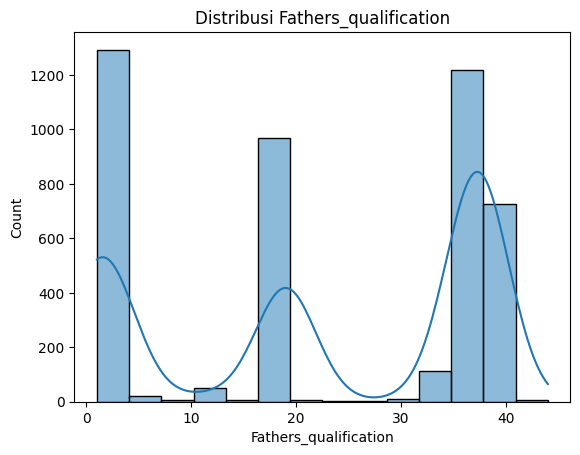

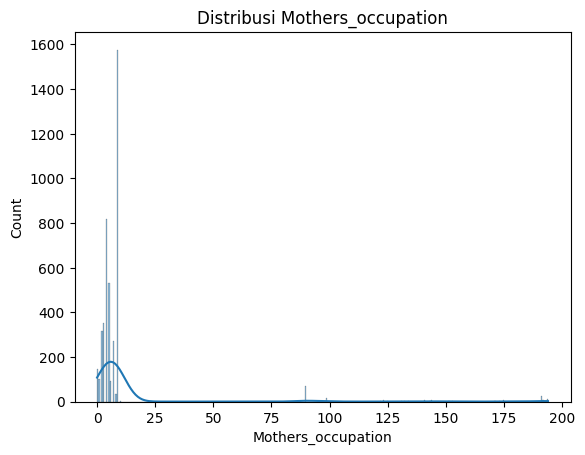

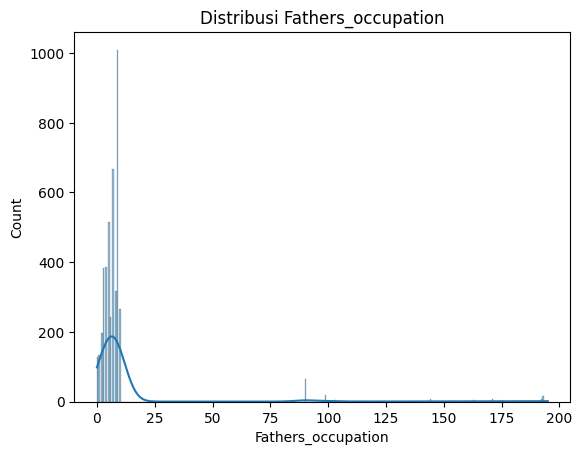

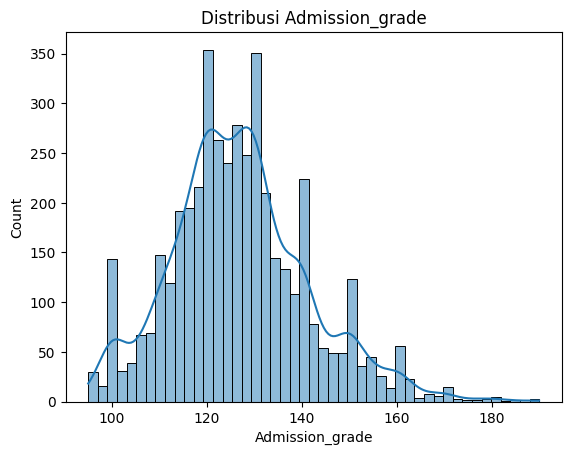

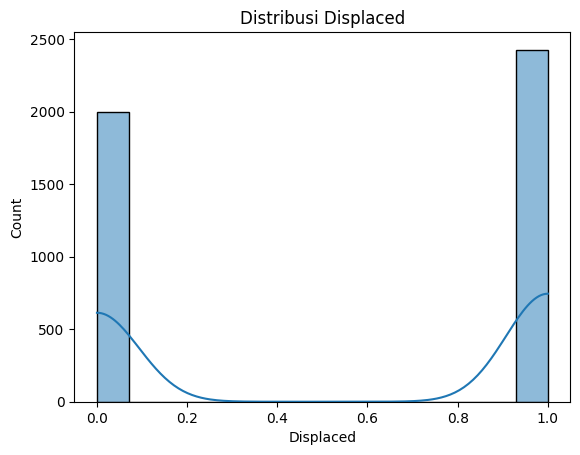

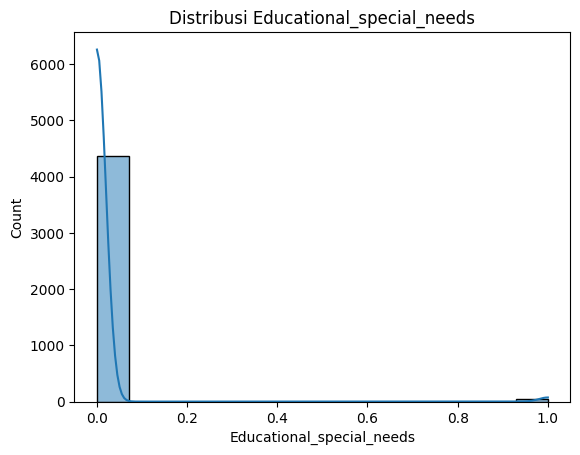

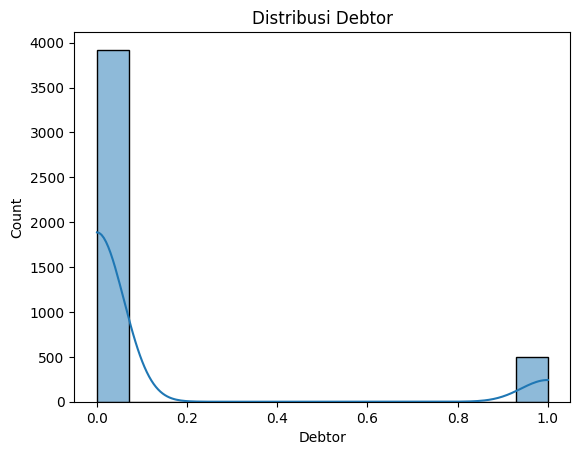

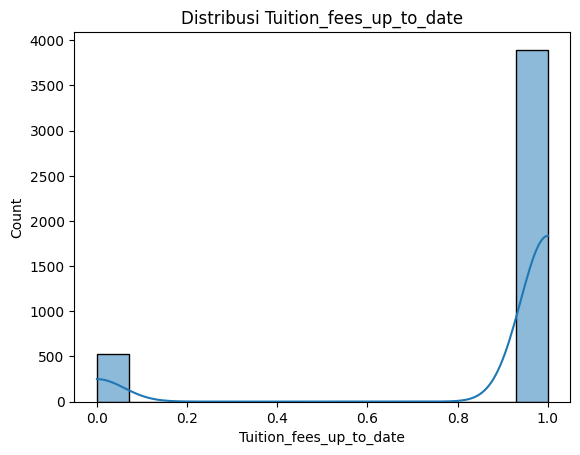

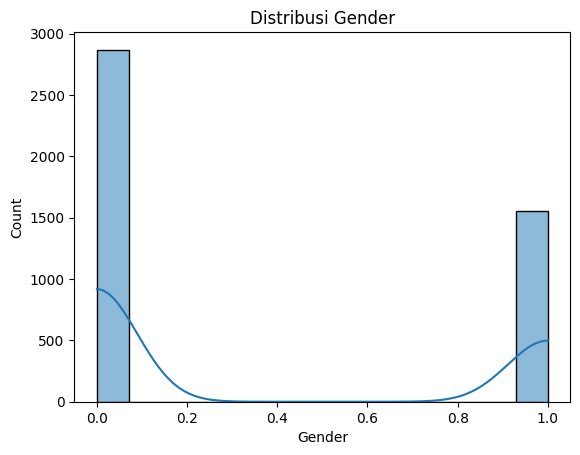

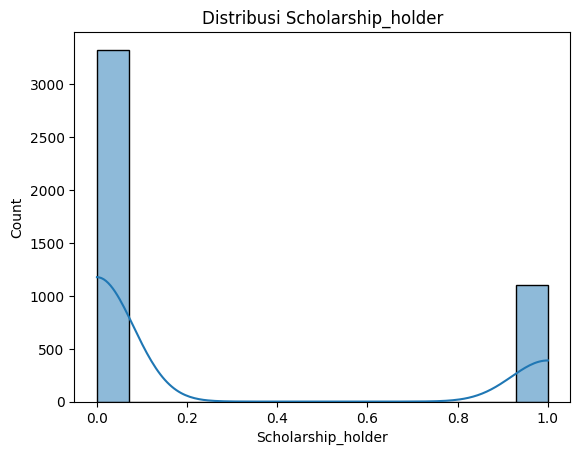

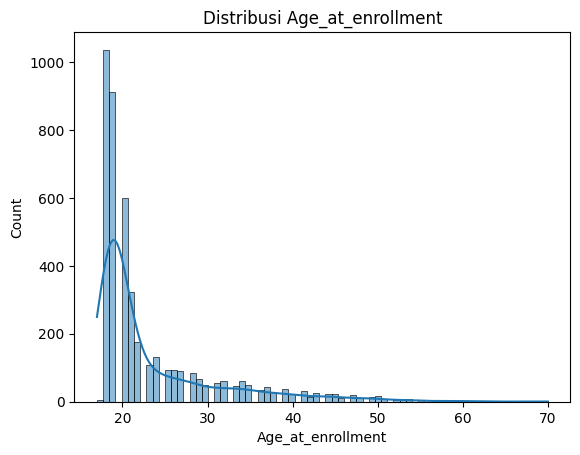

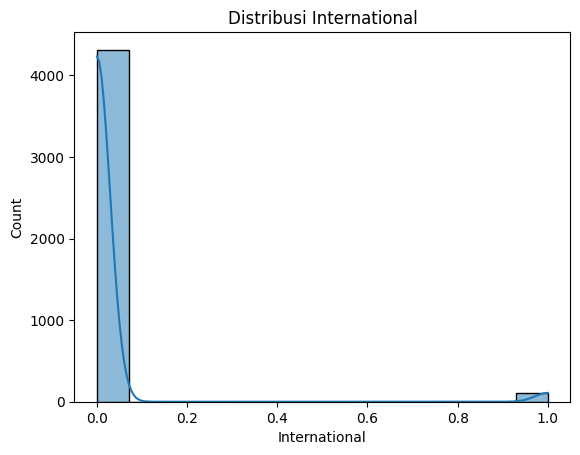

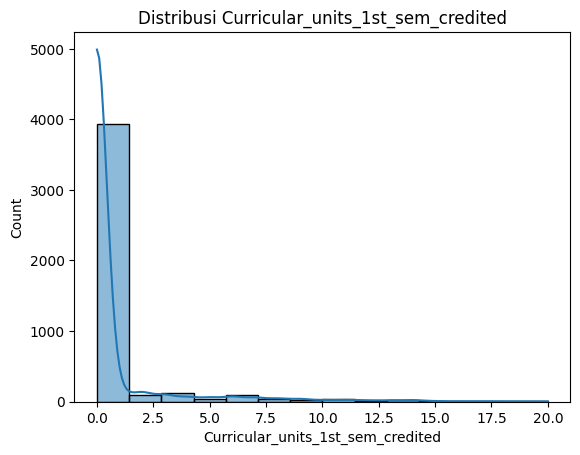

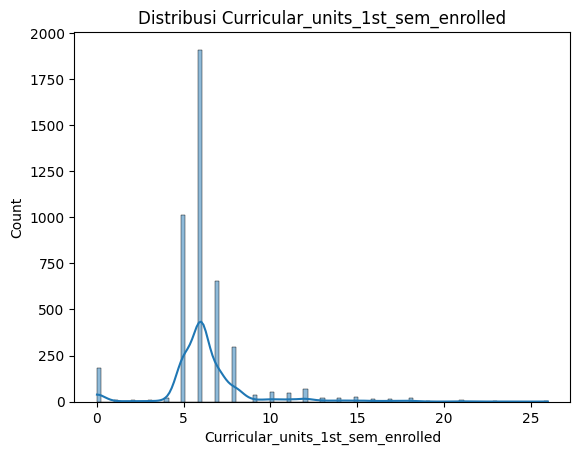

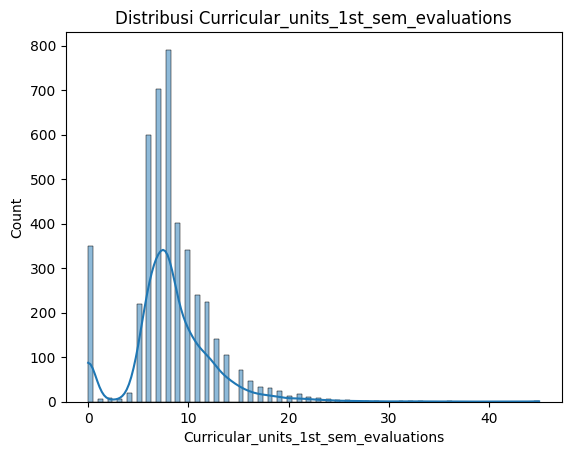

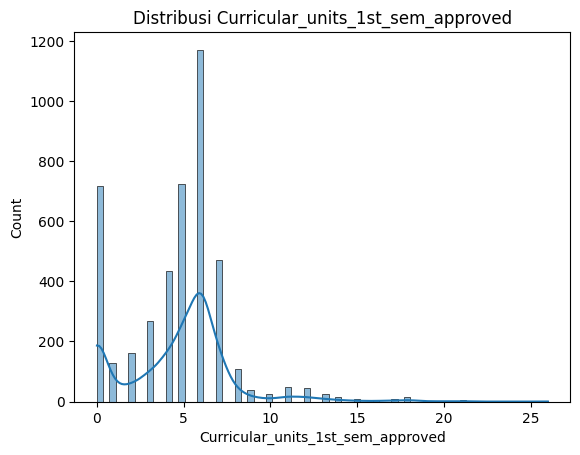

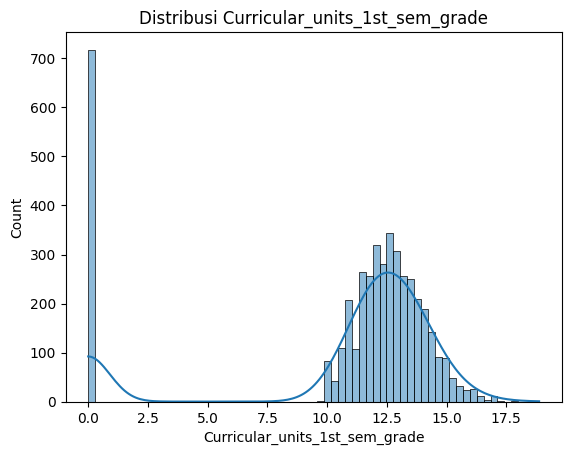

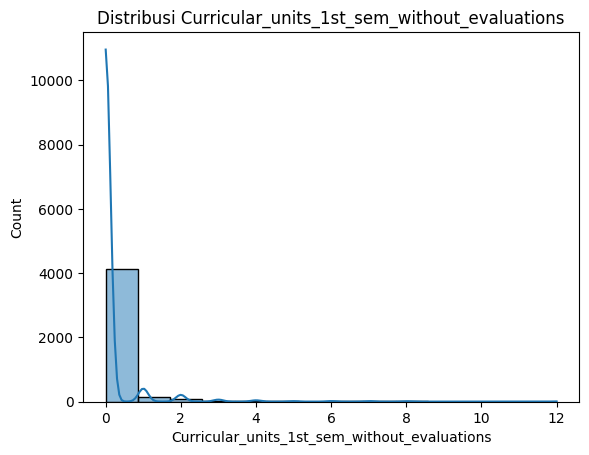

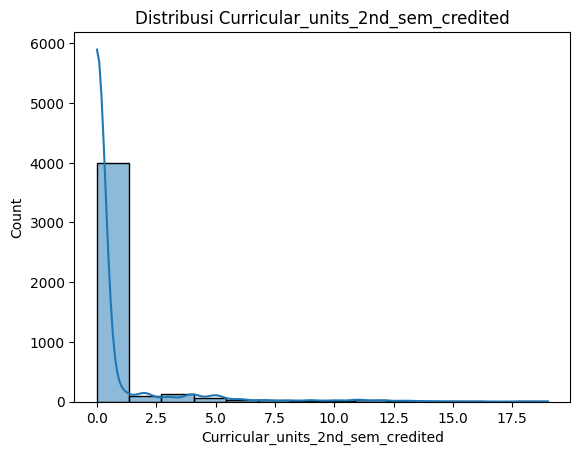

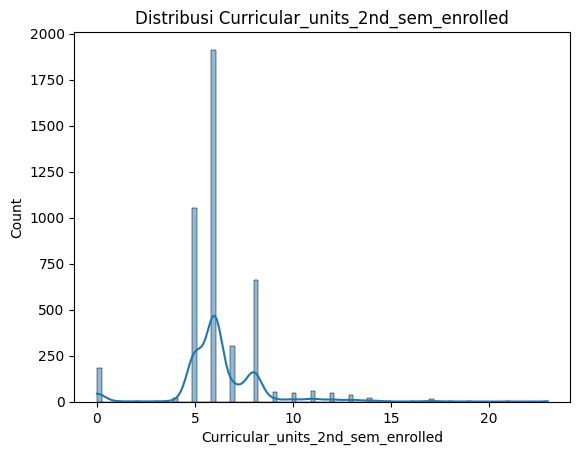

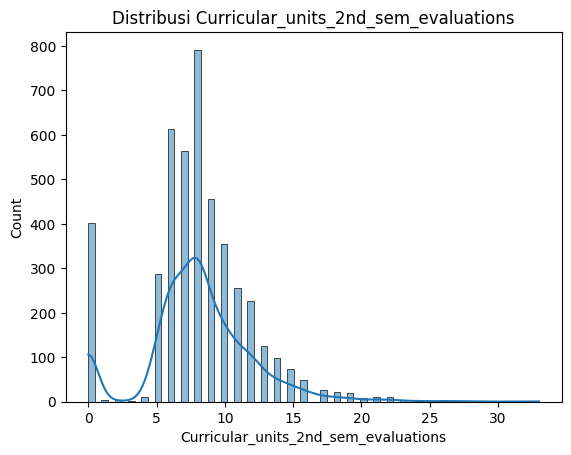

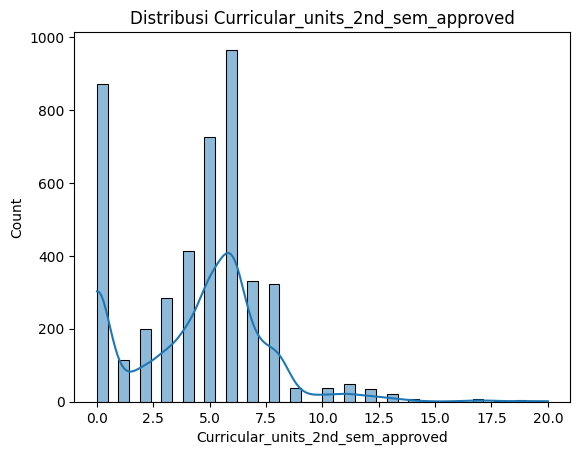

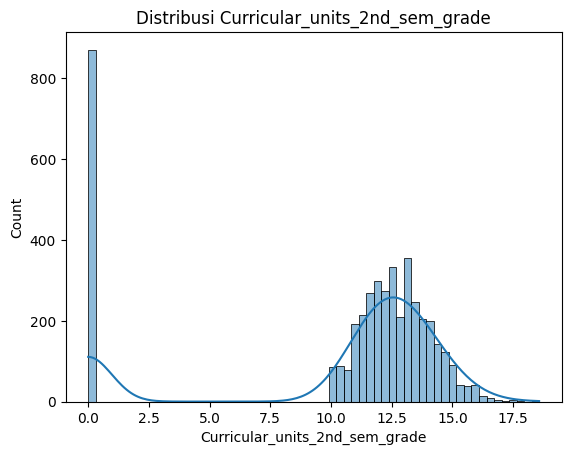

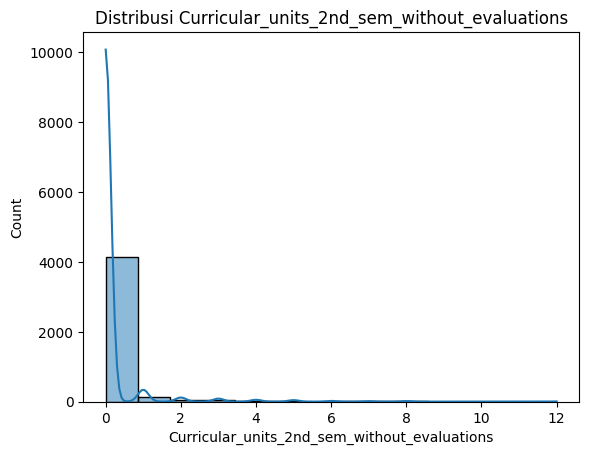

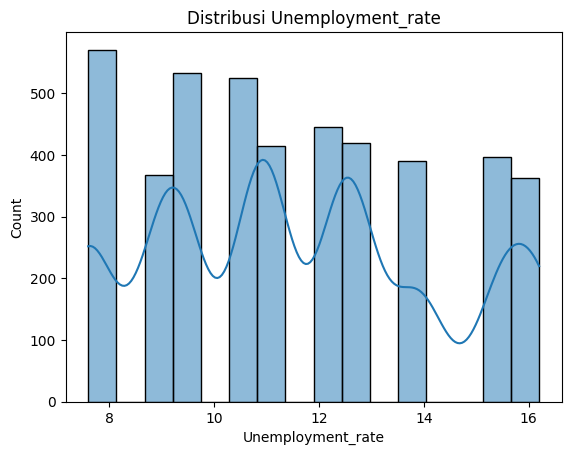

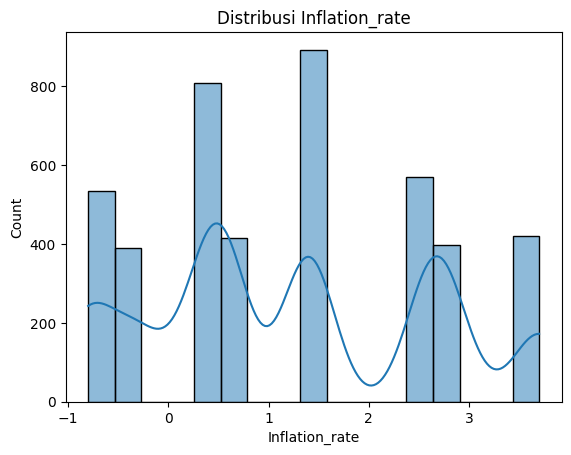

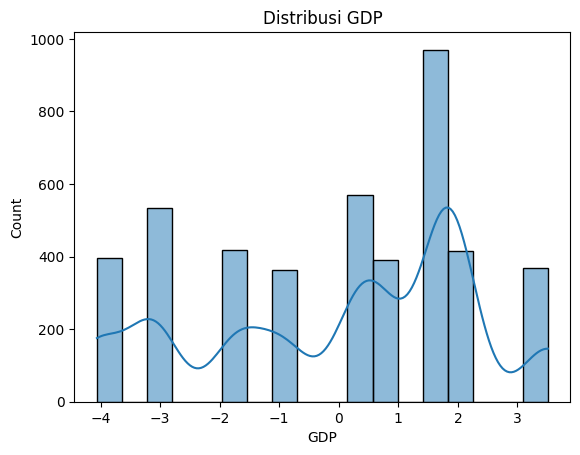

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

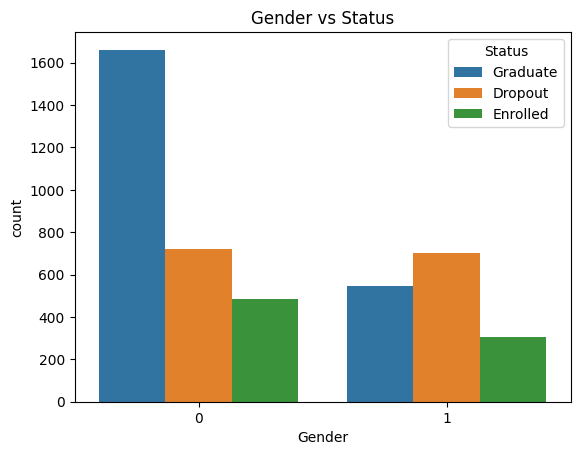

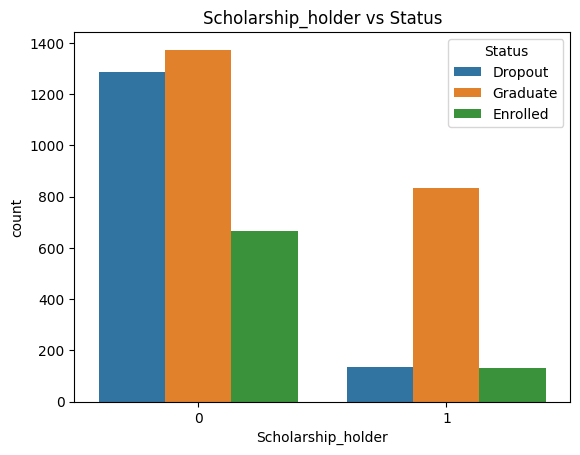

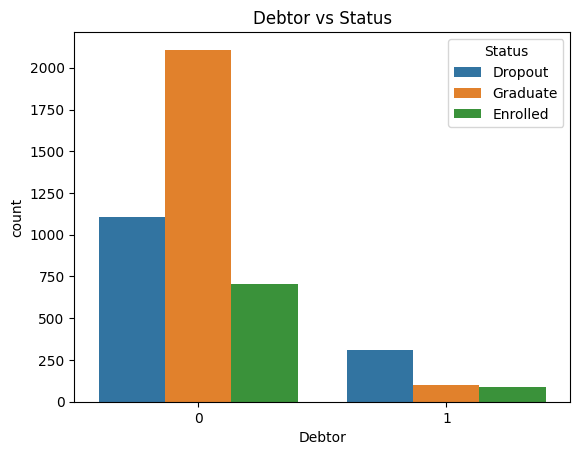

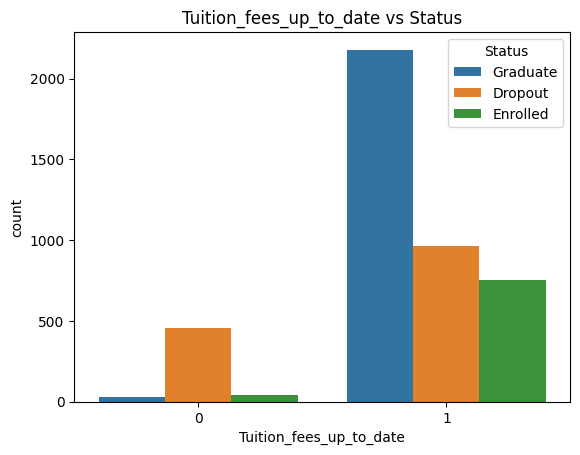

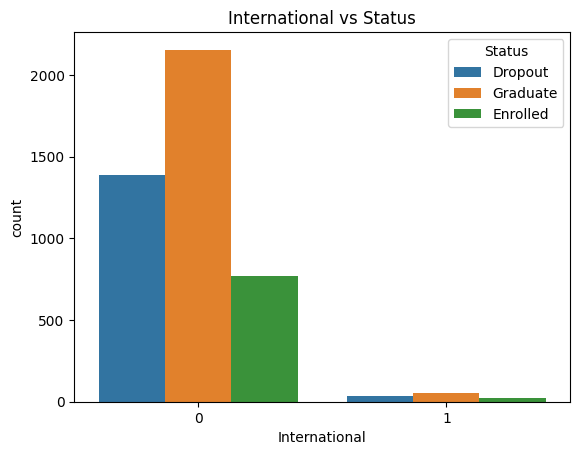

In [17]:
important_cat = [
    'Gender',
    'Scholarship_holder',
    'Debtor',
    'Tuition_fees_up_to_date',
    'International'
]

for col in important_cat:
    plt.figure()
    sns.countplot(x=col, hue='Status', data=df)
    plt.title(f'{col} vs Status')
    plt.show()

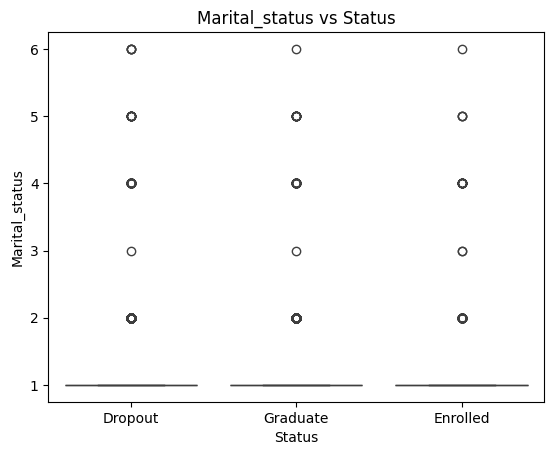

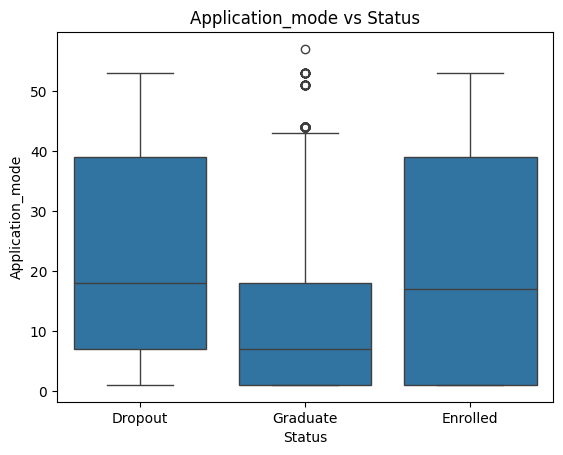

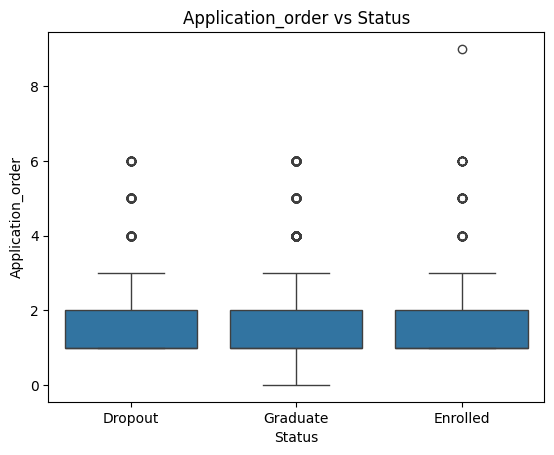

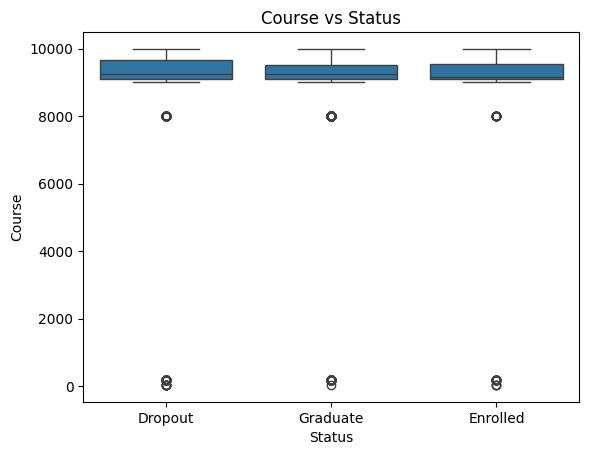

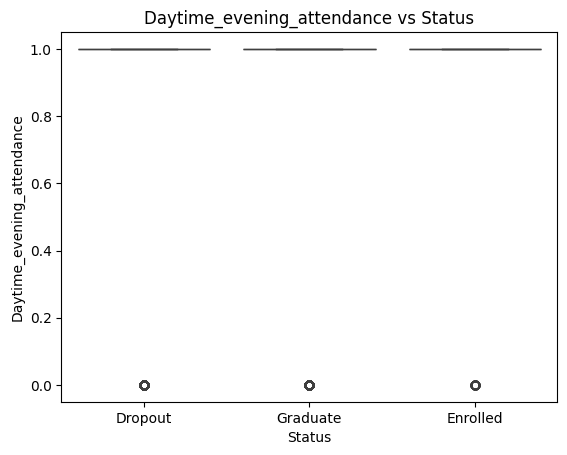

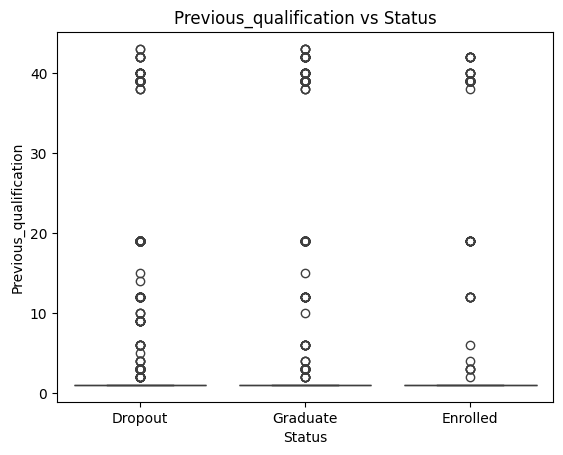

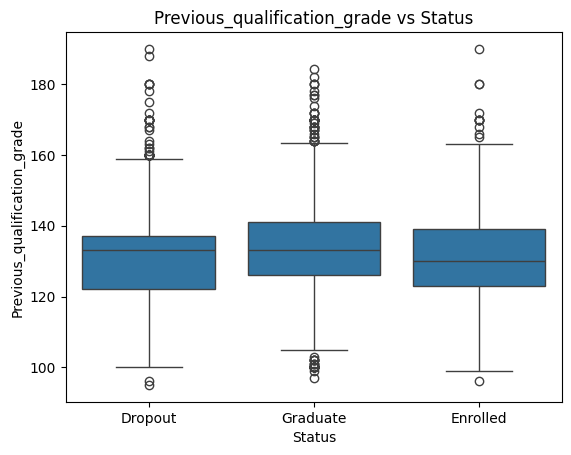

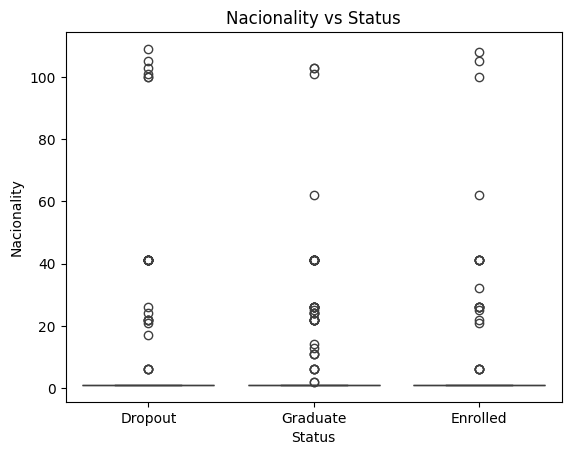

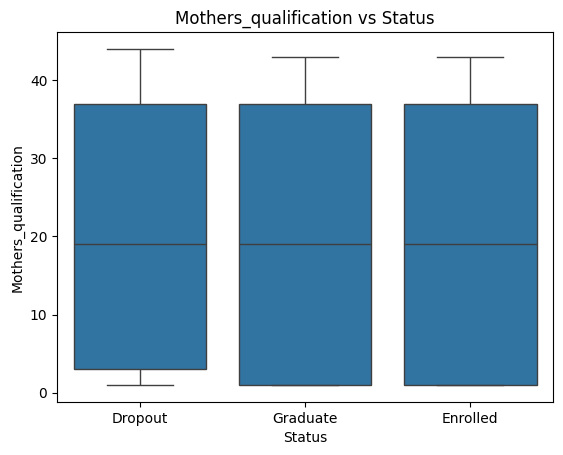

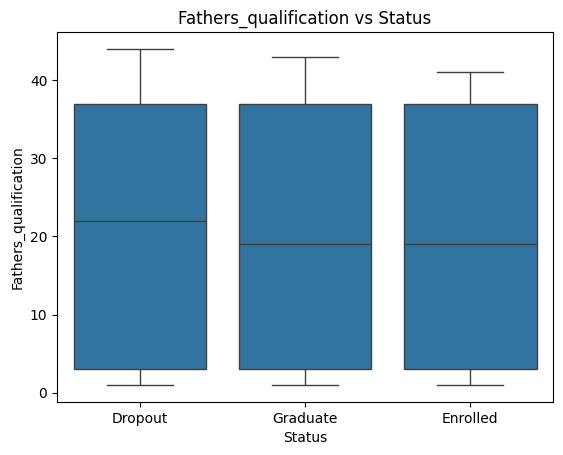

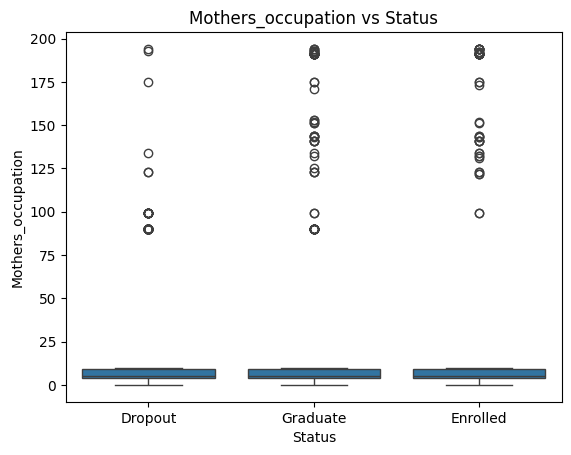

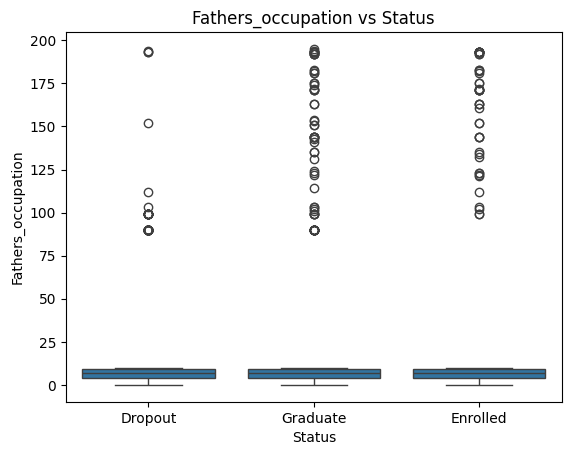

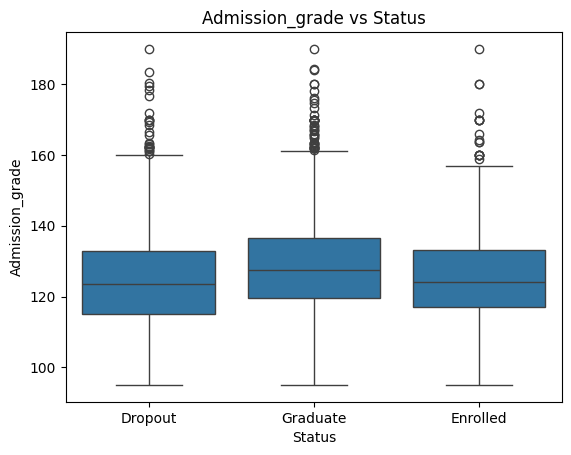

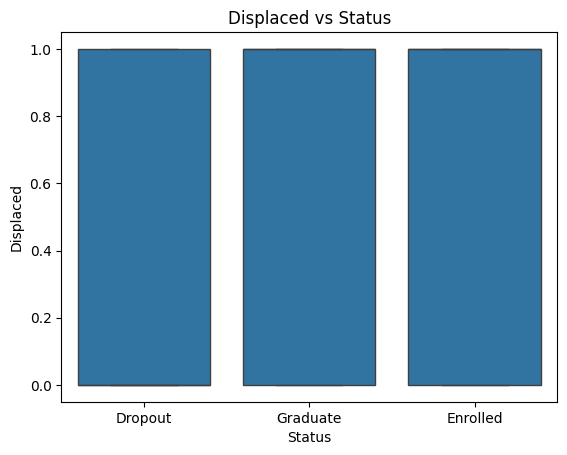

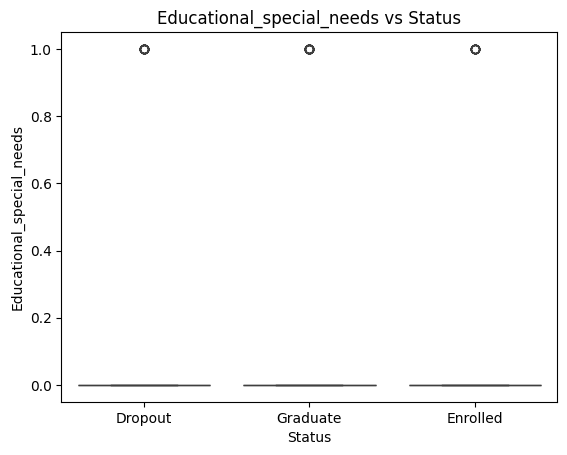

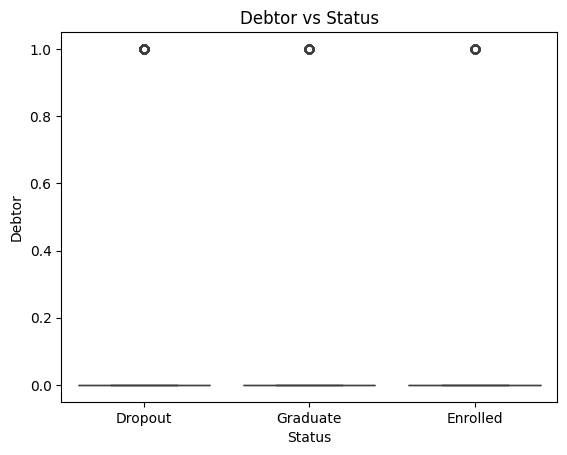

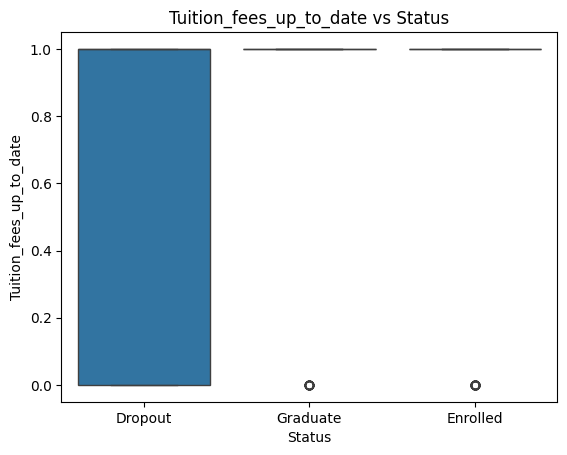

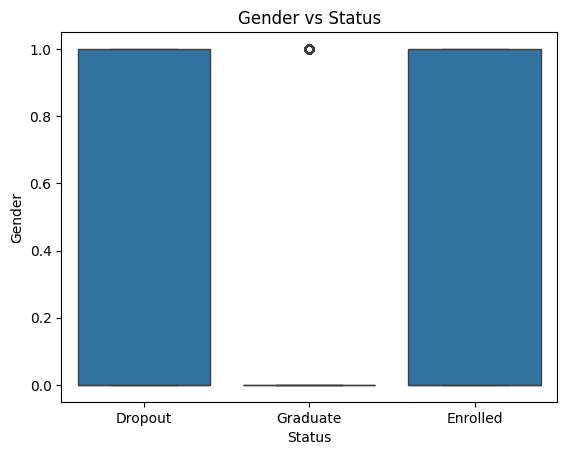

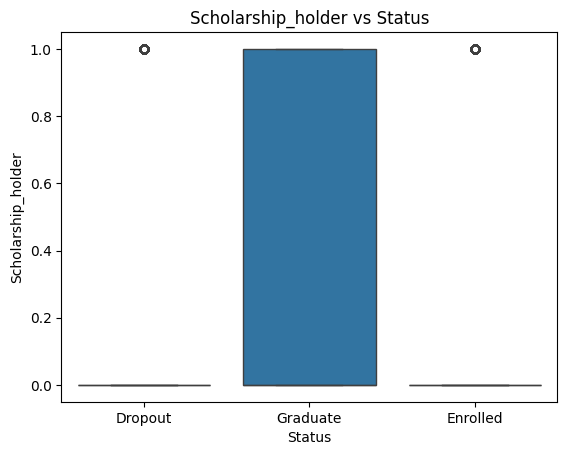

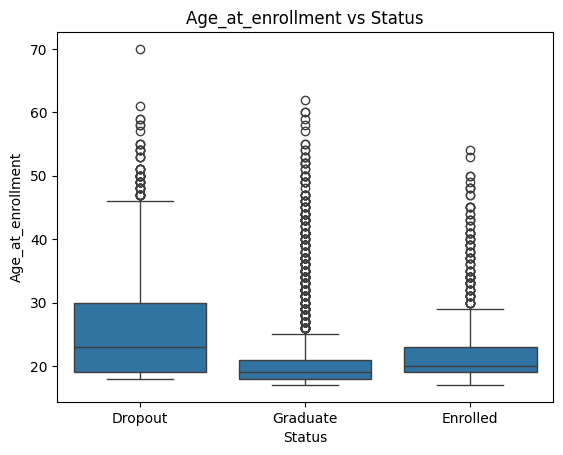

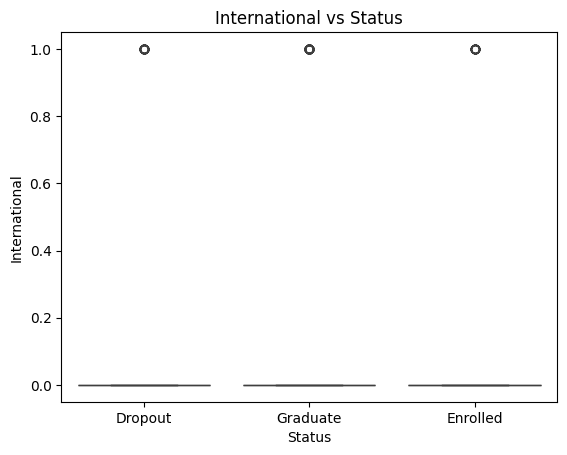

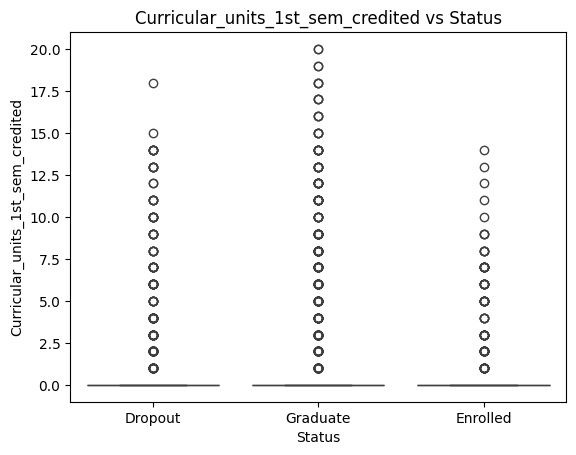

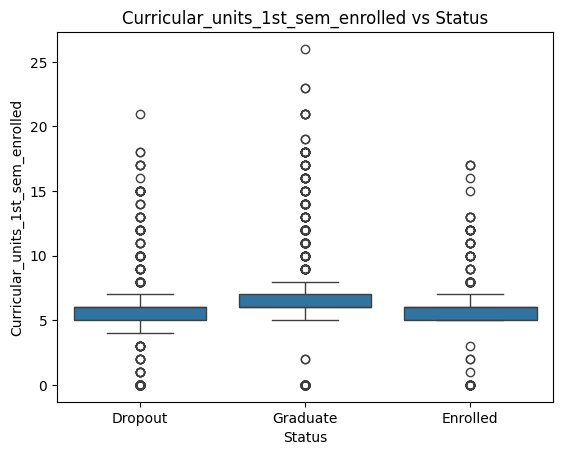

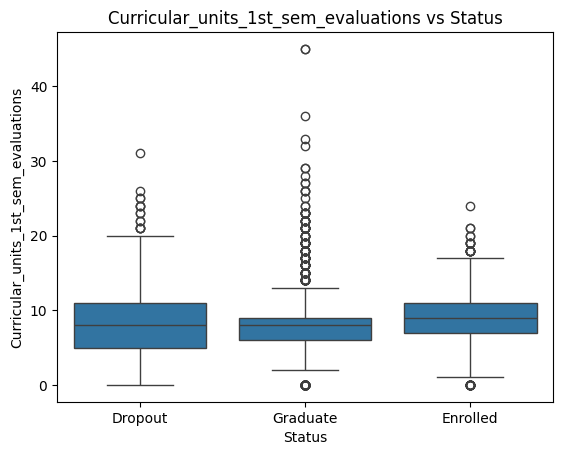

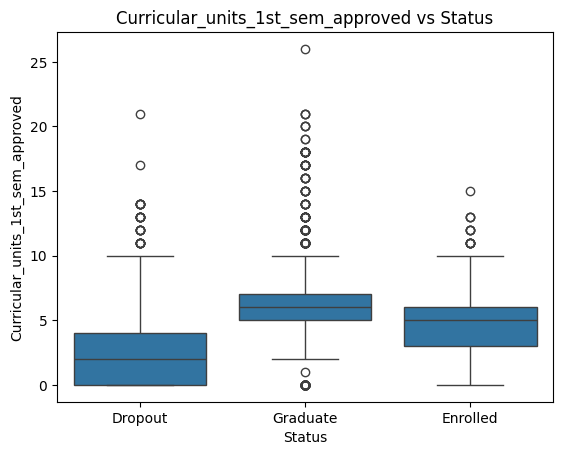

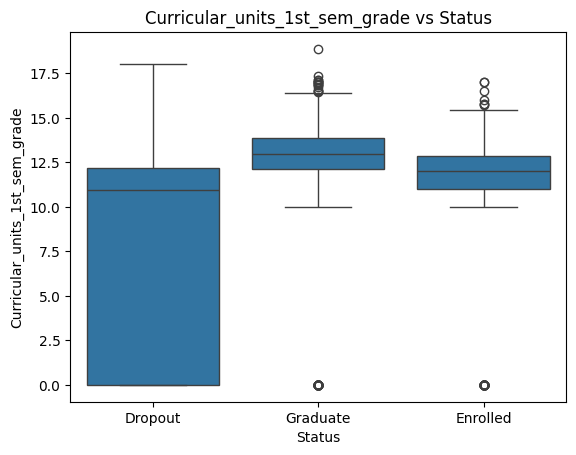

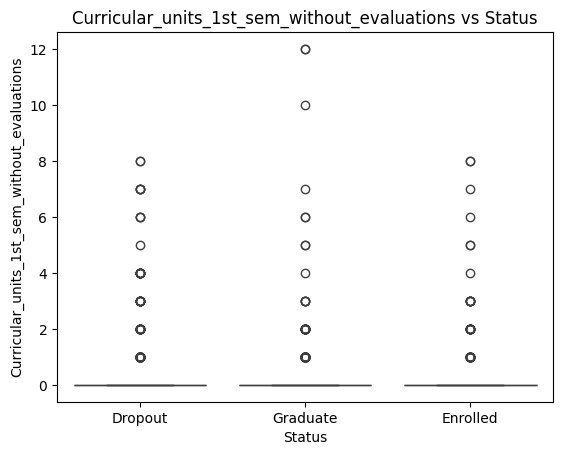

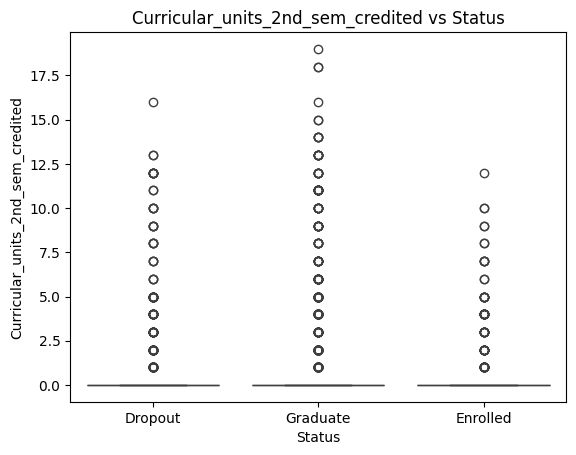

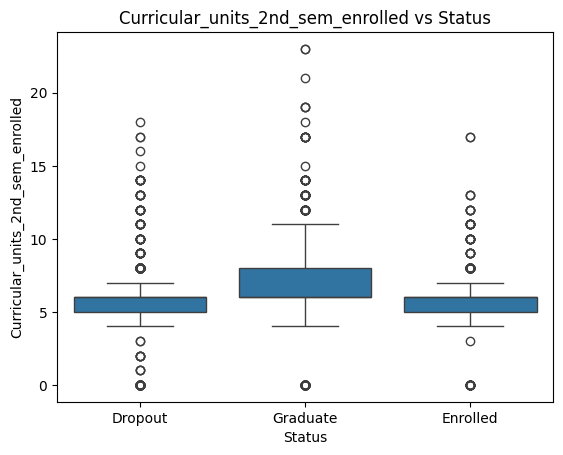

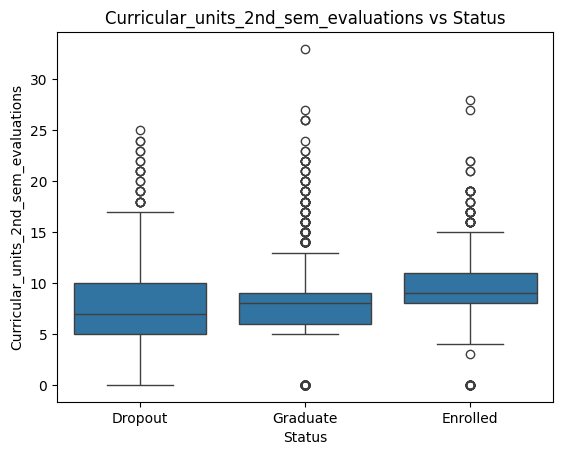

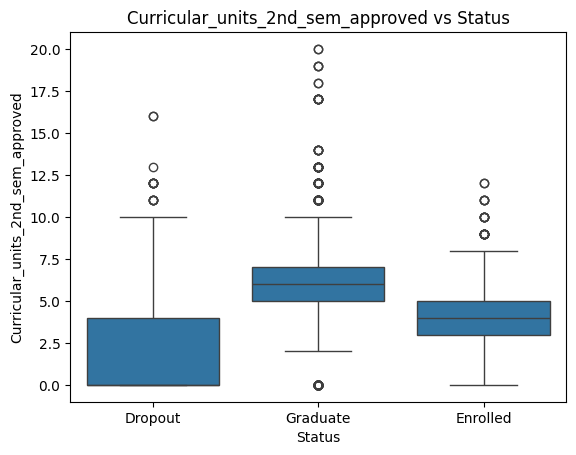

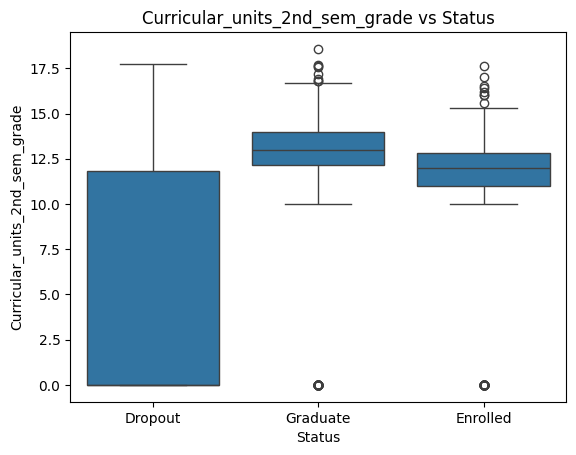

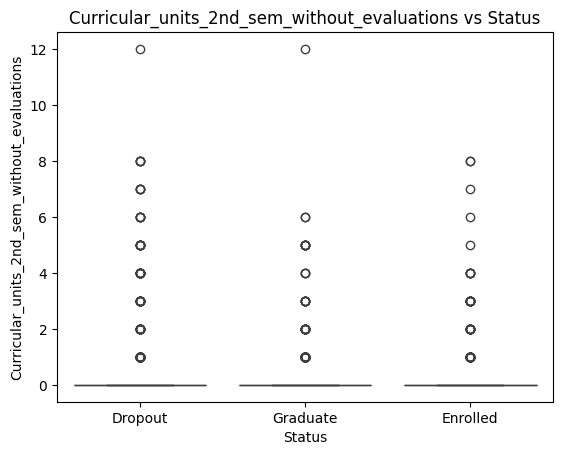

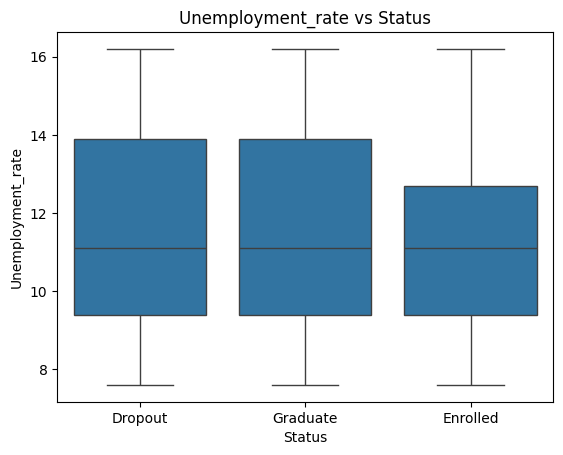

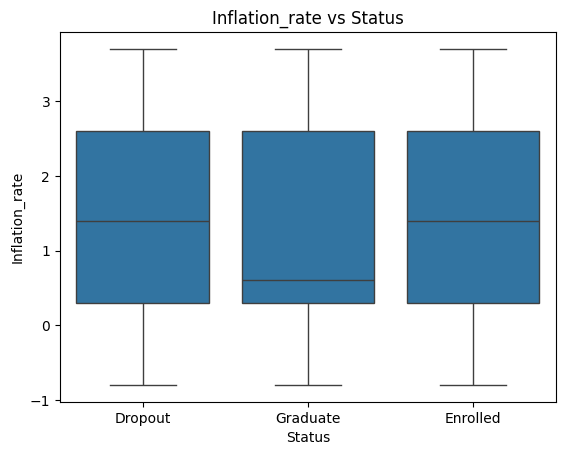

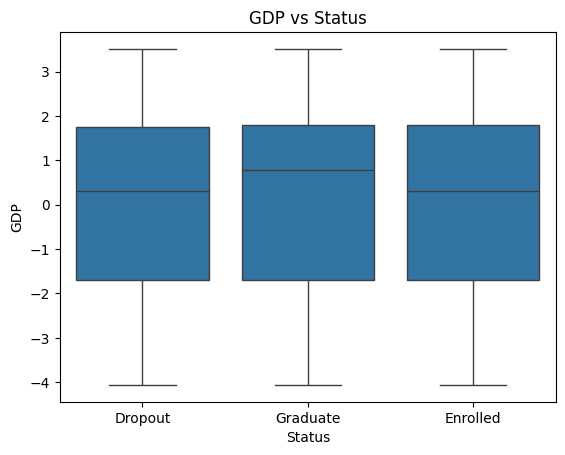

In [18]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x='Status', y=col, data=df)
    plt.title(f'{col} vs Status')
    plt.show()

## Data Preparation / Preprocessing

In [19]:
#le = LabelEncoder()
#df['Status'] = le.fit_transform(df['Status'])

df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

# Encode target manual (lebih aman & jelas)
df_model['Status'] = df_model['Status'].map({
    'Dropout': 0,
    'Graduate': 1
})

print(df_model['Status'].value_counts())

Status
1    2209
0    1421
Name: count, dtype: int64


In [20]:
print(df_model['Status'].isna().sum())

0


In [21]:
print(df_model['Status'].unique())

[0 1]


In [22]:
df_model['Status'].value_counts()

Status
1    2209
0    1421
Name: count, dtype: int64

In [23]:
# 1. Total approved units
df_model['Total_Approved_Units'] = (
    df_model['Curricular_units_1st_sem_approved'] +
    df_model['Curricular_units_2nd_sem_approved']
)

# 2. Grade trend
df_model['Grade_Trend'] = (
    df_model['Curricular_units_2nd_sem_grade'] -
    df_model['Curricular_units_1st_sem_grade']
)

# 3. Academic success rate
df_model['Academic_Success_Rate'] = (
    df_model['Total_Approved_Units'] /
    (df_model['Curricular_units_1st_sem_enrolled'] +
     df_model['Curricular_units_2nd_sem_enrolled'] + 1e-5)
)

# 4. Financial risk
df_model['Financial_High_Risk'] = (
    (df_model['Debtor'] == 1) &
    (df_model['Tuition_fees_up_to_date'] == 0)
).astype(int)

# 5. Parents education
df_model['Parents_Edu_Level'] = (
    df_model['Mothers_qualification'] +
    df_model['Fathers_qualification']
) / 2

In [24]:
for col in df_model.columns:
    if df_model[col].dtype == 'float64':
        df_model[col] = df_model[col].astype('float32')
    if df_model[col].dtype == 'int64':
        df_model[col] = df_model[col].astype('int32')

print("Data Preparation Selesai. Dimensi Data:", df.shape)

Data Preparation Selesai. Dimensi Data: (4424, 37)


In [25]:
X = df_model.drop('Status', axis=1)
y = df_model['Status']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
# Copy biar aman dari warning
X_train = X_train.copy()
X_test = X_test.copy()

categorical_cols = [
    'Marital_status', 'Application_mode', 'Application_order', 'Course', 
    'Daytime_evening_attendance', 'Previous_qualification', 'Nacionality', 
    'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 
    'Fathers_occupation', 'Displaced', 'Educational_special_needs', 'Debtor', 
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International',
    'Financial_High_Risk'
]

numerical_cols = [col for col in X.columns if col not in categorical_cols]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaling selesai untuk kolom numerik.")

Scaling selesai untuk kolom numerik.


In [28]:
print(f"Distribusi sebelum SMOTE: {Counter(y_train)}")

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Lakukan Resampling hanya pada data TRAINING
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Distribusi setelah SMOTE: {Counter(y_train_resampled)}")

Distribusi sebelum SMOTE: Counter({1: 1767, 0: 1137})
Distribusi setelah SMOTE: Counter({1: 1767, 0: 1767})


## Modeling

In [31]:
categorical_cols = [
    'Marital_status', 'Application_mode', 'Course', 'Gender', 
    'Scholarship_holder', 'Tuition_fees_up_to_date', 'Debtor',
    'Financial_High_Risk' # Fitur baru kategori
]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), # Menangani data tidak seimbang secara otomatis
    ('classifier', RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, # Ditambah agar tidak overfitting
        random_state=42
    ))
])

model_pipeline.fit(X_train, y_train)

print("Pipeline berhasil dilatih!")

Pipeline berhasil dilatih!


In [32]:
# Pemisahan kolom
categorical_cols = [
    'Marital_status', 'Application_mode', 'Course', 'Gender', 
    'Scholarship_holder', 'Tuition_fees_up_to_date', 'Debtor',
    'Financial_High_Risk'
]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [34]:
# Susun Pipeline
dt_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Parameter Tuning
param_grid_dt = {
    'classifier__max_depth': [5, 7, 10, None],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__min_samples_leaf': [1, 5, 10]
}

# GridSearch
grid_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=3, n_jobs=-1, verbose=1)
grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)
print("\nLaporan Klasifikasi Decision Tree:")

y_pred = grid_dt.predict(X_test)

print("\nLaporan Klasifikasi Decision Tree:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Dropout', 'Graduate']
))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best DT Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10}

Laporan Klasifikasi Decision Tree:

Laporan Klasifikasi Decision Tree:
              precision    recall  f1-score   support

     Dropout       0.92      0.84      0.88       284
    Graduate       0.90      0.95      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



In [35]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

# Susun Pipeline untuk Logistic Regression
lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Parameter Tuning untuk Logistic Regression
param_grid_lr = {
    'classifier__C': [1.0],
    'classifier__solver': ['lbfgs']
}

# GridSearch untuk Logistic Regression
grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=3, n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print("Training Logistic Regression Selesai!")
print("Parameter Terbaik:", grid_lr.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Training Logistic Regression Selesai!
Parameter Terbaik: {'classifier__C': 1.0, 'classifier__solver': 'lbfgs'}


## Evaluation

In [38]:
# Prediksi menggunakan pipeline
y_pred = model_pipeline.predict(X_test)

print("Laporan Klasifikasi:")
y_pred = grid_dt.predict(X_test)

print("\nLaporan Klasifikasi Decision Tree:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Dropout', 'Graduate']
))

Laporan Klasifikasi:

Laporan Klasifikasi Decision Tree:
              precision    recall  f1-score   support

     Dropout       0.92      0.84      0.88       284
    Graduate       0.90      0.95      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



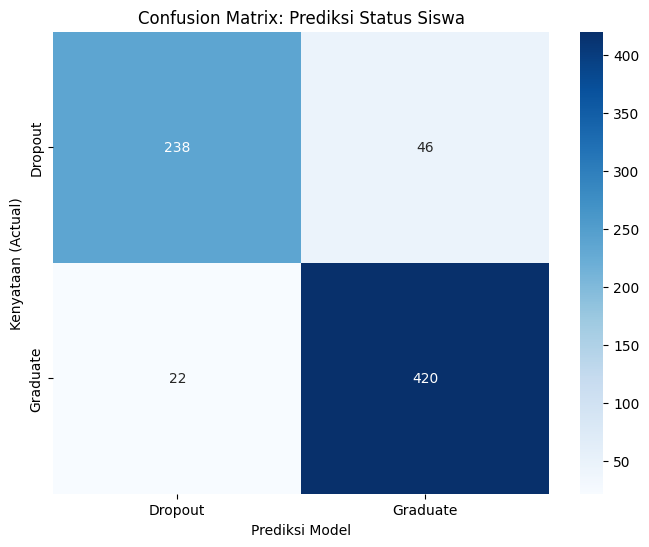

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dropout', 'Graduate'], 
            yticklabels=['Dropout', 'Graduate'])
plt.title('Confusion Matrix: Prediksi Status Siswa')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Actual)')
plt.show()

C:\Users\Bima Indra\AppData\Local\Temp\ipykernel_16260\112811307.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_importance.head(10), palette='magma')


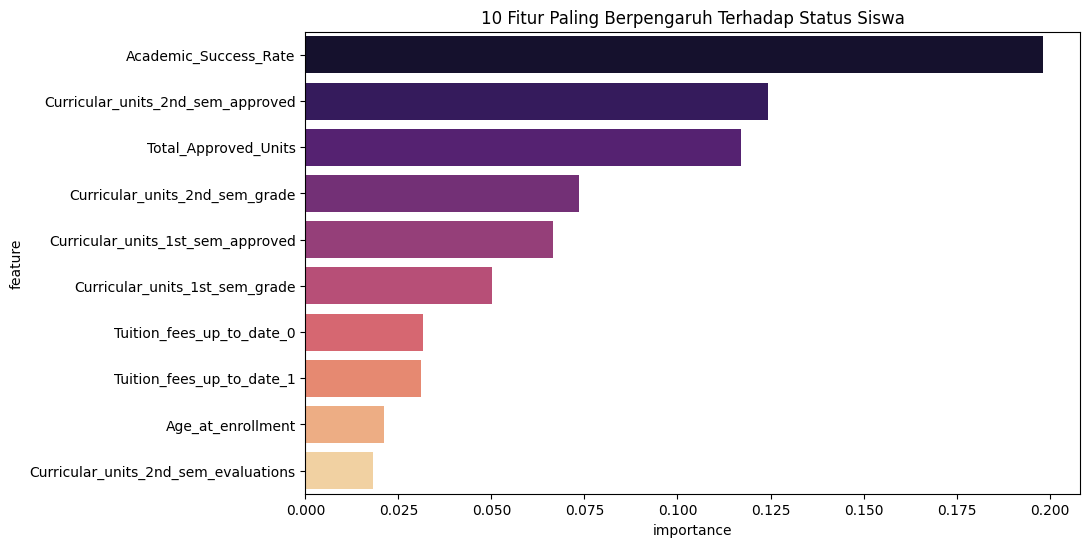

In [40]:
# Mengambil nama fitur setelah proses OneHotEncoding
# Fitur numerik tetap, fitur kategorikal bertambah jumlahnya karena OHE
cat_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

# Mengambil skor importance dari classifier
importances = model_pipeline.named_steps['classifier'].feature_importances_

# Membuat DataFrame untuk visualisasi
feat_importance = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_importance = feat_importance.sort_values('importance', ascending=False)

# Visualisasi 10 Fitur Teratas
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_importance.head(10), palette='magma')
plt.title('10 Fitur Paling Berpengaruh Terhadap Status Siswa')
plt.show()

=== EVALUASI LOGISTIC REGRESSION ===


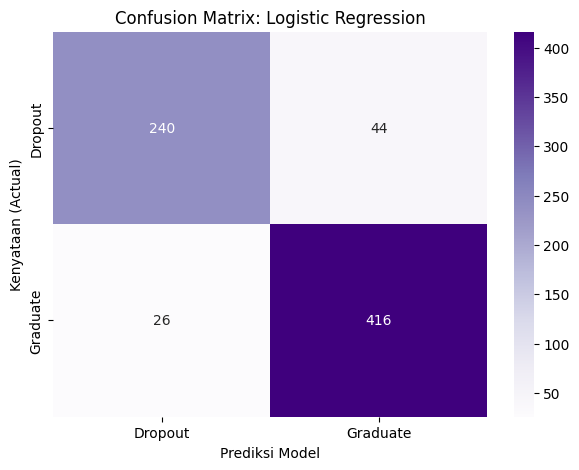

In [43]:
# --- LANGKAH PREDIKSI ---
y_pred_lr = grid_lr.predict(X_test)

# Cetak Laporan
print("=== EVALUASI LOGISTIC REGRESSION ===")

# Visualisasi Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Dropout', 'Graduate'], 
            yticklabels=['Dropout', 'Graduate'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Actual)')
plt.show()

=== EVALUASI DECISION TREE ===
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       284
           1       0.90      0.95      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



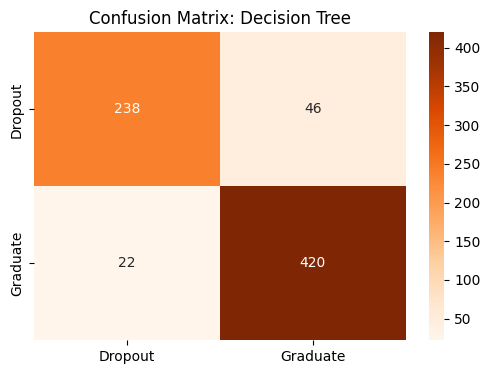

In [45]:
y_pred_dt = grid_dt.predict(X_test)

# Cetak Laporan
print("=== EVALUASI DECISION TREE ===")
print(classification_report(y_test, y_pred_dt))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Dropout', 'Graduate'], 
            yticklabels=['Dropout', 'Graduate'])
plt.title('Confusion Matrix: Decision Tree')
plt.show()

=== EVALUASI LOGISTIC REGRESSION ===


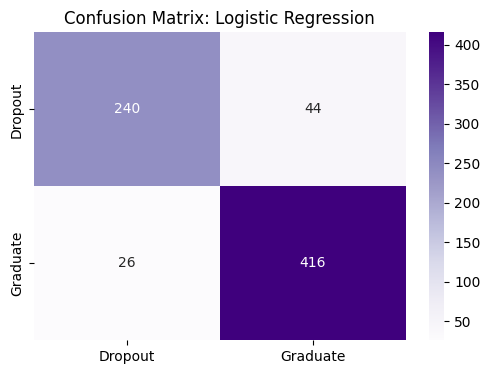

In [46]:
# --- LANGKAH PREDIKSI (PENTING AGAR TIDAK NAMEERROR) ---
y_pred_lr = grid_lr.predict(X_test)

# Cetak Laporan
print("=== EVALUASI LOGISTIC REGRESSION ===")

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Dropout', 'Graduate'], 
            yticklabels=['Dropout', 'Graduate'])
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [47]:
# Menghitung skor
results = {
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_lr)],
    'F1-Score (Weighted)': [f1_score(y_test, y_pred_dt, average='weighted'), 
                             f1_score(y_test, y_pred_lr, average='weighted')]
}

df_compare = pd.DataFrame(results)
print("=== PERBANDINGAN PERFORMA MODEL AKHIR ===")
print(df_compare)

=== PERBANDINGAN PERFORMA MODEL AKHIR ===
                 Model  Accuracy  F1-Score (Weighted)
0        Decision Tree  0.906336             0.905508
1  Logistic Regression  0.903581             0.902966


In [51]:
# Mengambil model terbaik dari hasil GridSearch Logistic Regression
best_lr_model = grid_lr.best_estimator_

# Menyimpan model (pipeline lengkap)
joblib.dump(best_lr_model, 'model_logistic_regression.pkl')

print("Model Logistic Regression berhasil disimpan!")

Model Logistic Regression berhasil disimpan!


In [52]:
# Ambil model terbaik dari GridSearch Decision Tree
best_dt_model = grid_dt.best_estimator_

# Simpan model (sudah termasuk preprocessing + SMOTE dalam pipeline)
joblib.dump(best_dt_model, 'model_decision_tree.pkl')

print("Model Decision Tree berhasil disimpan!")

Model Decision Tree berhasil disimpan!


In [53]:
df.to_csv('data_student_performance_metabase.csv', index=False)